# 01 Price EDA

Data: `bloomberg_data/Prices.csv`, 492 weeks, 2011-01-07 to 2020-06-05. Each value: mean of five daily settlements.

Output: `data/prices_clean.csv`, `results/price_eda_scorecard.csv`.


**Reviewer orientation — what is this notebook for?**

Think of this notebook as the quality-control room before any trading idea is allowed.

You started with a big spreadsheet of fuel prices (`Prices.csv`). This notebook asks one question at a time, in plain language:

1. Do we have enough weeks of data to trust this price?
2. Are the numbers in comparable units?
3. Are there copy-paste errors or calendar quirks?
4. Does this price wander forever, or does it snap back toward a normal level?
5. How fast does it snap back, and how big is a normal weekly move?
6. Which prices are just copies of each other in disguise?

Only the prices that snap back fast enough and move enough survive to the next notebook. Everything else is dropped with a written reason. No trading, no forecasts yet — just deciding what is even worth testing.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf, grangercausalitytests
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
import warnings
warnings.filterwarnings('ignore')   # KPSS p-value table bounds

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 200)
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True

**What the toolbox block just did — no math yet.**

This block only loads tools. Think of it like laying out kitchen tools before cooking: tables (`pandas`), charts (`matplotlib`), and statistics kits (`statsmodels`, `scipy`). The last two lines just say "don't scare me with warnings" and "show wide tables." Nothing is calculated here. If this block fails, it means a library is missing, not that your data is wrong.


In [2]:
# files and settings
PRICE_FILE = '../bloomberg_data/Prices.csv'
TICKER_FILE = '../bloomberg_data/bbg_tickers_fields.csv'

PRE_COVID_END = '2020-02-28'    # last pre-COVID week
COVID_START = '2020-03-06'
MIN_WEEKS = 260                 # five years

GAL_PER_BBL = 42
BBL_PER_MT_JET = 7.88           # bbl per tonne, jet
BBL_PER_MT_GASOIL = 7.45        # bbl per tonne, gasoil

os.makedirs('../data', exist_ok=True)
os.makedirs('../results', exist_ok=True)

**What the settings block just did.**

This block writes down the ground rules so every later result can be reproduced. It says: prices live in this file, ticker descriptions live in that file, COVID starts March 2020, and we require 5 years (260 weeks) of history to trust a series. It also writes down the kitchen conversions: 42 gallons in a barrel, and how many barrels are in a tonne of jet vs gasoil. Think of it as pinning the recipe to the wall before cooking.


## 1. Inventory


In [3]:
PRICES = pd.read_csv(PRICE_FILE, index_col=0)
PRICES = PRICES.loc[:, ~PRICES.columns.str.startswith('Unnamed')]
PRICES.index = pd.to_datetime(PRICES.index, format='%m/%d/%Y')
PRICES.index.name = 'week_ending'
print(PRICES.shape)
print(PRICES.index.min().date(), 'to', PRICES.index.max().date())
PRICES.iloc[:5, :8]

(492, 126)
2011-01-07 to 2020-06-05


,AKDCM1 Index,AKDCM2 Index,AKDCM3 Index,AKDCM4 Index,AKDCM5 Index,AKDCM6 Index,CL1 Comdty,CL2 Comdty
week_ending,,,,,,,,
2011-01-07,NaN,NaN,NaN,NaN,NaN,NaN,89.53,90.65
2011-01-14,NaN,NaN,NaN,NaN,NaN,NaN,91.03,92.14
2011-01-21,NaN,NaN,NaN,NaN,NaN,NaN,90.05,91.09
2011-01-28,NaN,NaN,NaN,NaN,NaN,NaN,87.27,89.35
2011-02-04,NaN,NaN,NaN,NaN,NaN,NaN,90.68,93.31


**What this block did — taking stock of the fridge.**

It opened `Prices.csv` and asked: how many weeks do we have, from when to when? Each column is one price (for example LA jet for delivery next month). Each row is one Friday. The block prints the shape (rows × columns) and shows the first few rows so you can see with your eyes that dates look like dates and prices look like numbers. No analysis yet — just confirming the delivery arrived.


In [4]:
# ticker names and units
TICKERS = pd.read_csv(TICKER_FILE, index_col=0)
TICKERS = TICKERS.reindex(PRICES.columns)
TICKERS[['short_name', 'unit']].iloc[::6]    # M1 ticker per product

,short_name,unit
AKDCM1 Index,Sin Jet Ker Cr Dub 1st Cr M1,USD/barrel
CL1 Comdty,Generic 1st 'CL' Future,USD/bbl.
CO1 Comdty,Generic 1st 'CO' Future,USD/bbl.
DJISM1 Index,BFV Jet vs GO Spread M1,USD/barrel
FEJSM1 Index,Med Jet- ICE Gasoil Fair Value,USD/metric tonne
FGJSM1 Index,USGC Jet Fuel-Nymex HO Fair Va,USd/gallon
FJMNM1 Index,Jet Med FOB vs Jet NWE CIF M1,USD/metric tonne
FJSBM1 Index,Fair Value Jet Crack M1,USD/barrel
FLJSM1 Index,LA Jet Fuel-Nymex HO Fair Valu,USd/gallon
FNJSM1 Index,NY Jet Fuel-Nymex HO Fair Valu,USd/gallon


**What this block did — reading the labels on the jars.**

Prices arrive with cryptic codes like `FSLJM1 Index`. This block opens the ticker file that says what each code means in plain English and what unit it was quoted in — dollars per barrel, dollars per tonne, cents per gallon. It shows one row per product so you can spot-check. Example: LA jet vs Brent crude live in totally different units, so you cannot subtract them yet. This table tells you which conversion each column will need next.


Per column: start, end, weeks with data, share of weeks equal to the prior week (a repeat marks a filled value).


In [5]:
INVENTORY = pd.DataFrame(index=PRICES.columns)
INVENTORY['root'] = [c.split()[0][:-1] for c in PRICES.columns]
INVENTORY['month'] = [int(c.split()[0][-1]) for c in PRICES.columns]
INVENTORY['name'] = TICKERS['short_name']
INVENTORY['unit'] = TICKERS['unit']

for col in PRICES.columns:
    s = PRICES[col].dropna()
    INVENTORY.loc[col, 'first_week'] = s.index.min().date()
    INVENTORY.loc[col, 'last_week'] = s.index.max().date()
    INVENTORY.loc[col, 'weeks_with_data'] = len(s)
    INVENTORY.loc[col, 'missing_inside'] = PRICES.loc[s.index.min():s.index.max(), col].isna().sum()
    INVENTORY.loc[col, 'share_unchanged'] = round((s.diff() == 0).mean(), 3)

INVENTORY[INVENTORY['month'] == 1]

,root,month,name,unit,first_week,last_week,weeks_with_data,missing_inside,share_unchanged
AKDCM1 Index,AKDCM,1,Sin Jet Ker Cr Dub 1st Cr M1,USD/barrel,2019-12-06,2020-06-05,27.0,0.0,0.000
CL1 Comdty,CL,1,Generic 1st 'CL' Future,USD/bbl.,2011-01-07,2020-06-05,492.0,0.0,0.004
CO1 Comdty,CO,1,Generic 1st 'CO' Future,USD/bbl.,2011-01-07,2020-06-05,492.0,0.0,0.002
DJISM1 Index,DJISM,1,BFV Jet vs GO Spread M1,USD/barrel,2018-03-09,2020-06-05,118.0,0.0,0.008
FEJSM1 Index,FEJSM,1,Med Jet- ICE Gasoil Fair Value,USD/metric tonne,2011-01-07,2020-06-05,487.0,5.0,0.002
FGJSM1 Index,FGJSM,1,USGC Jet Fuel-Nymex HO Fair Va,USd/gallon,2011-01-07,2020-06-05,492.0,0.0,0.020
FJMNM1 Index,FJMNM,1,Jet Med FOB vs Jet NWE CIF M1,USD/metric tonne,2020-01-03,2020-06-05,23.0,0.0,0.043
FJSBM1 Index,FJSBM,1,Fair Value Jet Crack M1,USD/barrel,2019-01-04,2020-06-05,75.0,0.0,0.000
FLJSM1 Index,FLJSM,1,LA Jet Fuel-Nymex HO Fair Valu,USd/gallon,2011-01-07,2020-06-05,492.0,0.0,0.008
FNJSM1 Index,FNJSM,1,NY Jet Fuel-Nymex HO Fair Valu,USd/gallon,2011-01-07,2020-06-05,492.0,0.0,0.073


**What this block did — health check per price.**

For every single price column it asks: when does it start and end, how many weeks are filled, are there holes in the middle, and how often is the value exactly the same as last week? A price that never moves is suspicious — it usually means someone filled a missing value by copying last week. This table is the evidence for what gets dropped next.


In [6]:
# drop products under 260 weeks
SHORT_ROOTS = INVENTORY.loc[INVENTORY['weeks_with_data'] < MIN_WEEKS, 'root'].unique().tolist()
print('dropped:', SHORT_ROOTS)
PRICES = PRICES[INVENTORY.index[~INVENTORY['root'].isin(SHORT_ROOTS)]]
INVENTORY = INVENTORY.loc[PRICES.columns]
print(PRICES.shape)

dropped: ['AKDCM', 'DJISM', 'FJMNM', 'FJSBM']
(492, 102)


**What this block did — throwing out short histories.**

It drops any product family with fewer than 260 weeks (5 years). Four families are dropped here. Why? Every later test needs years of ups and downs to tell luck from skill. A price that only exists for 2 years cannot be tested fairly, so it is removed now and the reason is printed.


In [7]:
# share of repeated weekly values
UNCHANGED = INVENTORY.pivot(index='root', columns='month', values='share_unchanged')
UNCHANGED

month,1,2,3,4,5,6
root,,,,,,
CL,0.004,0.002,0.000,0.002,0.002,0.000
CO,0.002,0.000,0.002,0.002,0.006,0.002
FEJSM,0.002,0.000,0.000,0.000,0.000,0.000
FGJSM,0.020,0.016,0.026,0.022,0.016,0.028
FLJSM,0.008,0.024,0.071,0.083,0.102,0.126
FNJSM,0.073,0.091,0.120,0.120,0.130,0.124
FSEJM,0.000,0.002,0.000,0.000,0.000,0.002
FSGJM,0.000,0.000,0.002,0.002,0.002,0.004
FSLJM,0.000,0.000,0.002,0.000,0.002,0.000


**What this block did — where do frozen values live?**

It reshapes the "share unchanged" numbers into a small grid: rows are products, columns are delivery months 1 to 6. You can see at a glance that flat prices almost never freeze, but LA and NY calendar differences freeze 7-13% of weeks. That matters because a frozen price looks calm but it is really missing data in disguise.


- Dropped, under 260 weeks: AKDCM, DJISM, FJMNM, FJSBM.
- Repeated values: flat curves 0 to 0.6 percent of weeks; LA diff M3-M6 7 to 13 percent; NY diff 7 to 13 percent; REJSM 6 to 7 percent.


## 2. Units: c/gal

Barrel = 42 gallons. Tonne = 7.88 barrels (jet), 7.45 barrels (gasoil).


In [8]:
UNIT_FACTOR = {}
for col in PRICES.columns:
    unit = str(INVENTORY.loc[col, 'unit']).lower()
    root = INVENTORY.loc[col, 'root']
    if 'gal' in unit:
        UNIT_FACTOR[col] = 1.0
    elif 'bbl' in unit or 'barrel' in unit:
        UNIT_FACTOR[col] = 100 / GAL_PER_BBL
    elif root == 'QS':
        UNIT_FACTOR[col] = 100 / (BBL_PER_MT_GASOIL * GAL_PER_BBL)
    else:
        UNIT_FACTOR[col] = 100 / (BBL_PER_MT_JET * GAL_PER_BBL)

CG = PRICES.copy()
for col in CG.columns:
    CG[col] = CG[col] * UNIT_FACTOR[col]

pd.Series(UNIT_FACTOR).groupby(INVENTORY['unit']).first()

unit
USD/MT              0.319591
USD/barrel          2.380952
USD/bbl.            2.380952
USD/metric tonne    0.302151
USd/gal.            1.000000
USd/gallon          1.000000
dtype: float64

**What this block did — putting everything in the same currency.**

Some prices are quoted per gallon, some per barrel, some per tonne. You cannot subtract them until they share a unit. This block picks the right conversion for each column and creates a new table `CG` in cents per gallon. Think dollars-to-euros before comparing prices: 1 barrel = 42 gallons, 1 tonne of jet = 7.88 barrels. After this, "LA minus Gulf Coast = 5" always means 5 cents per gallon.


In [9]:
# 2019 means, c/gal
M1_COLS = [c for c in CG.columns if c.split()[0].endswith('1')]
CHECK_2019 = pd.DataFrame({'name': INVENTORY.loc[M1_COLS, 'name'], 'mean_2019_cents_per_gal': CG.loc['2019', M1_COLS].mean().round(1)})
CHECK_2019

,name,mean_2019_cents_per_gal
CL1 Comdty,Generic 1st 'CL' Future,135.6
CO1 Comdty,Generic 1st 'CO' Future,152.6
FEJSM1 Index,Med Jet- ICE Gasoil Fair Value,5.7
FGJSM1 Index,USGC Jet Fuel-Nymex HO Fair Va,-7.4
FLJSM1 Index,LA Jet Fuel-Nymex HO Fair Valu,2.2
FNJSM1 Index,NY Jet Fuel-Nymex HO Fair Valu,-0.7
FSEJM1 Index,Med Jet FOB Cargo FV Month 1,184.3
FSGJM1 Index,USGC Jet Fuel FV Month 1,186.4
FSLJM1 Index,LA Jet Fuel FV Month 1,196.0
FSNJM1 Index,New York Jet Fuel FV Month 1,193.1


**What this block did — sanity check on the conversion.**

It averages every front-month price over 2019 and prints them. You as a reviewer just ask: do these look like real fuel prices (roughly 150-200 cents per gallon in 2019)? If one showed 5 or 5000, the unit conversion above would be wrong. This is the "does the answer smell right" test.


## 3. Special weeks

NY early-week equality check, month-change weeks, COVID weeks.


In [10]:
NY_COPY = PRICES.index[PRICES['FSNJM1 Index'] == PRICES['FSGJM1 Index']]
print(len(NY_COPY), 'weeks where NY jet M1 equals Gulf Coast jet M1 to the cent')
print(list(NY_COPY.strftime('%Y-%m-%d')))

27 weeks where NY jet M1 equals Gulf Coast jet M1 to the cent
['2011-01-07', '2011-01-14', '2011-01-21', '2011-01-28', '2011-02-04', '2011-02-11', '2011-03-18', '2011-04-15', '2011-04-22', '2011-04-29', '2011-06-10', '2011-06-17', '2011-06-24', '2011-07-01', '2011-07-08', '2011-09-16', '2011-09-23', '2011-09-30', '2013-10-11', '2014-04-25', '2014-05-02', '2014-05-09', '2014-05-16', '2014-05-23', '2014-05-30', '2014-06-20', '2014-07-11']


**What this block did — checking early New York prices against Gulf Coast (read carefully).**

It counts weeks where New York jet M1 equals Gulf Coast jet M1 to the cent: 27 weeks, scattered from 2011-01-07 to 2014-07-11, never after. Checked against `bloomberg_data/Prices.csv` directly, this is NOT a solid block of copied data and NOT a conversion error in this notebook:

- Of the 27 flat-equal weeks, 19 are also diff-equal (both legs identical); 8 are flat-equal but diff-different, all eight in 2014-04-25 to 2014-07-11.
- On those 8 weeks the Gulf Coast leg is internally consistent (flat minus diff matches HO2 within ~0.2c, the normal fit), while the New York leg is off by 3 to 5c. So the inconsistency sits in the NY diff leg, not a simple flat-price copy.
- Outside the equal weeks the early data look real: non-equal 2011 weeks show NY-GC spreads up to +11.5c and down to -9.3c; 2012 has zero equal weeks; 2013 has one. A wholesale copy would not produce that.
- By year, share exactly equal (M1): 2011 34.6%, 2012 0%, 2013 1.9%, 2014 15.4%, 2015 onward 0%. LA vs Gulf Coast as a control is never exactly equal (0 of 492).

Best reading: an intermittent upstream feed issue — most likely Bloomberg publishing a Gulf Coast fallback as the New York fair value when the NY market was illiquid or the ticker had not properly launched — not forgery, not someone hand-copying, and not a unit-conversion bug (all four tickers are natively USd/gal per `bbg_tickers_fields.csv`; HO is USd/gal too, so no barrel/gallon mix-up can produce exact equality). The notebook's response is conservative hygiene, not an accusation: quarantine all NY history before 2014-07-18 next, because we cannot tell which early non-equal weeks are clean. Limitation to remember: this discards 184 weeks and keeps 308; the 2014-07-18 start date is a judgment call (last equal week was 2014-07-11, plus one week margin), not a proven clean-room date.


In [11]:
# NY series start 2014-07-18
NY_CLEAN_START = '2014-07-18'
NY_COLS = [c for c in CG.columns if c.startswith('FSNJM') or c.startswith('FNJSM')]
CG.loc[:'2014-07-11', NY_COLS] = np.nan
print(NY_COLS)

['FNJSM1 Index', 'FNJSM2 Index', 'FNJSM3 Index', 'FNJSM4 Index', 'FNJSM5 Index', 'FNJSM6 Index', 'FSNJM1 Index', 'FSNJM2 Index', 'FSNJM3 Index', 'FSNJM4 Index', 'FSNJM5 Index', 'FSNJM6 Index']


**What this block did — quarantining early New York history (conservative, not a forgery verdict).**

It sets every New York column (FSNJM and FNJSM, all six months) to missing up to 2014-07-11, keeping data from 2014-07-18 onward. Think of it as roping off a stretch of road with intermittent bad surfacing rather than tearing out forged pages: 27 of 184 early weeks are provably suspect, the rest are merely untrustworthy-by-association. From here on, NY averages and tests automatically skip those weeks. Cost of this caution: NY series drop from 492 to 308 weeks, and any pre-2014 NY-GC spread history (mean +1.4c) is excluded in favour of the post-2014 regime (mean +6.7c) — a regime change you should keep in mind when reading later results.


Implied heating oil contract per diff: jet price minus diff, against HO1 to HO4 (median absolute gap, c/gal).


In [12]:
HO_MATCH = pd.DataFrame(columns=['HO1', 'HO2', 'HO3', 'HO4'])
for region, flat, diff in [('LA', 'FSLJM', 'FLJSM'), ('GC', 'FSGJM', 'FGJSM'), ('NY', 'FSNJM', 'FNJSM')]:
    for n in [1, 2, 3]:
        implied_ho = CG[f'{flat}{n} Index'] - CG[f'{diff}{n} Index']
        for k in [1, 2, 3, 4]:
            HO_MATCH.loc[f'{region} jet M{n}', f'HO{k}'] = (implied_ho - CG[f'HO{k} Comdty']).abs().median()
HO_MATCH.astype(float).round(2)

,HO1,HO2,HO3,HO4
LA jet M1,0.81,0.17,0.83,1.62
LA jet M2,1.55,0.88,0.17,0.95
LA jet M3,2.40,1.69,0.99,0.17
GC jet M1,0.84,0.15,0.79,1.59
GC jet M2,1.55,0.87,0.15,0.88
GC jet M3,2.40,1.70,0.96,0.14
NY jet M1,0.91,0.24,0.80,1.70
NY jet M2,1.80,0.94,0.23,0.96
NY jet M3,2.60,1.89,1.03,0.22


**What this block did — which heating-oil contract is hidden inside the jet price?**

Jet fuel here is quoted as a "diff": jet price minus heating-oil price. But which heating-oil month? This block tries HO month 1, 2, 3, 4 and asks: which one makes the math line up best? It measures the typical (median) gap in cents. Answer: the next month (n+1) fits best, within about 0.2 cents. As a reviewer, read this as "we checked the fine print on how the diff is defined, so we don't compare apples to oranges."


In [13]:
# diff spread against flat spread
GAP_LA = ((CG['FLJSM1 Index'] - CG['FGJSM1 Index']) - (CG['FSLJM1 Index'] - CG['FSGJM1 Index'])).dropna()
GAP_NY = ((CG['FNJSM1 Index'] - CG['FGJSM1 Index']) - (CG['FSNJM1 Index'] - CG['FSGJM1 Index'])).dropna()
print('LA: median gap', round(GAP_LA.abs().median(), 3), '| weeks with gap above 0.05 c/gal:', (GAP_LA.abs() > 0.05).sum(), 'of', len(GAP_LA))
print('NY: median gap', round(GAP_NY.abs().median(), 3), '| weeks with gap above 0.05 c/gal:', (GAP_NY.abs() > 0.05).sum(), 'of', len(GAP_NY))

LA: median gap 0.0 | weeks with gap above 0.05 c/gal: 48 of 492
NY: median gap 0.0 | weeks with gap above 0.05 c/gal: 38 of 308


**What this block did — are diff spreads and flat spreads the same thing?**

There are two ways to compute "LA minus Gulf Coast": subtract the two jet prices directly, or subtract their two diffs. In theory they should match. This block checks the gap week by week. LA matches within 0.05 cents in 444 of 492 weeks — close enough to treat them as the same story. This matters because later we keep the flat version and drop the duplicate.


- Diff for jet M*n prices against HO*(n+1); median gap 0.14 to 0.24 c/gal.
- Diff spread equals flat spread within 0.05 c/gal: LA 444 of 492 weeks, NY 270 of 308.


Month-change week: Monday and Friday in different months (generic M1/M2 roll).


In [14]:
MONDAY = PRICES.index - pd.Timedelta(days=4)
MONTH_CHANGE_WEEK = pd.Series(MONDAY.month != PRICES.index.month, index=PRICES.index)
COVID_WEEK = pd.Series(PRICES.index >= COVID_START, index=PRICES.index)
print(MONTH_CHANGE_WEEK.sum(), 'month-change weeks out of', len(PRICES))
print(COVID_WEEK.sum(), 'COVID weeks')

65 month-change weeks out of 492
14 COVID weeks


**What this block did — marking calendar-roll weeks.**

Futures contracts "roll": one week the front month means June, next week it means July. If Monday and Friday fall in different calendar months, this week gets flagged as a month-change week. It also flags COVID weeks from March 2020 on. Think of sticking colored pins in a calendar so later you can ask "do strange moves just happen on roll weeks?"


In [15]:
ROLL = pd.DataFrame(columns=['avg_move_month_change_weeks', 'avg_move_other_weeks', 'ratio'])
for name, a, b in [('LA jet M1-M2', 'FSLJM1 Index', 'FSLJM2 Index'),
                   ('GC jet M1-M2', 'FSGJM1 Index', 'FSGJM2 Index'),
                   ('NY jet M1-M2', 'FSNJM1 Index', 'FSNJM2 Index'),
                   ('Heating oil M1-M2', 'HO1 Comdty', 'HO2 Comdty'),
                   ('WTI M1-M2', 'CL1 Comdty', 'CL2 Comdty'),
                   ('Brent M1-M2', 'CO1 Comdty', 'CO2 Comdty'),
                   ('NWE jet M1-M2', 'FSWJM1 Index', 'FSWJM2 Index')]:
    move = (CG[a] - CG[b]).loc[:PRE_COVID_END].diff().abs().dropna()
    flag = MONTH_CHANGE_WEEK.loc[move.index]
    ROLL.loc[name] = [move[flag].mean(), move[~flag].mean(), move[flag].mean() / move[~flag].mean()]
ROLL.astype(float).round(2)

,avg_move_month_change_weeks,avg_move_other_weeks,ratio
LA jet M1-M2,1.05,1.03,1.02
GC jet M1-M2,0.71,0.52,1.36
NY jet M1-M2,0.69,0.55,1.26
Heating oil M1-M2,0.31,0.58,0.54
WTI M1-M2,0.19,0.28,0.68
Brent M1-M2,0.32,0.42,0.76
NWE jet M1-M2,0.36,0.35,1.02


**What this block did — do roll weeks move more?**

It compares the average weekly move on flagged roll weeks vs normal weeks. Example: Gulf Coast jet time-spread moves 1.36x more on roll weeks. Futures move less (0.5-0.7x). As a reviewer: this is why the flag was saved — it proves the calendar effect is real but small, not a reason to delete those weeks, just to remember them.


- Mean weekly move of M1-M2, month-change weeks against other weeks: GC jet 1.36x, NY jet 1.26x, LA and NWE jet equal, futures 0.54x to 0.76x.
- Marker saved: `month_change_week`.


## 4. Candidate series (c/gal, M1 unless named)

| Group    | Series                                                          |
| -------- | --------------------------------------------------------------- |
| Flat     | LA, GC, NY jet; HO; WTI; Brent; gasoil; NWE jet; Singapore kero |
| Regional | LA_GC_1, LA_GC_2, NY_GC_1, NY_GC_2, LA_NY_1                     |
| Foreign  | NWE_GC_1, SING_GC_1                                             |
| Arb      | NY_NWE_1, LA_SING_1                                             |
| Time     | M1-M2, M2-M3, M1-M3 per product                                 |
| Diff     | LA, GC, NY jet minus HO                                         |
| Crack    | GC jet and HO against Brent and WTI                             |
| Other    | BRENT_WTI, HO_GASOIL, NWE_JET_GASOIL                            |


In [16]:
S = pd.DataFrame(index=CG.index)
GROUP = {}

# flat prices, M1
for name, col in [('LA_JET', 'FSLJM1 Index'), ('GC_JET', 'FSGJM1 Index'), ('NY_JET', 'FSNJM1 Index'), ('HO', 'HO1 Comdty'),
                  ('WTI', 'CL1 Comdty'), ('BRENT', 'CO1 Comdty'), ('GASOIL', 'QS1 Comdty'), ('NWE_JET', 'FSWJM1 Index'), ('SING_KERO', 'FSSKM1 Index')]:
    S[name] = CG[col]
    GROUP[name] = 'flat'

# regional spreads
S['LA_GC_1'] = CG['FSLJM1 Index'] - CG['FSGJM1 Index']
S['LA_GC_2'] = CG['FSLJM2 Index'] - CG['FSGJM2 Index']
S['NY_GC_1'] = CG['FSNJM1 Index'] - CG['FSGJM1 Index']
S['NY_GC_2'] = CG['FSNJM2 Index'] - CG['FSGJM2 Index']
S['LA_NY_1'] = CG['FSLJM1 Index'] - CG['FSNJM1 Index']
for name in ['LA_GC_1', 'LA_GC_2', 'NY_GC_1', 'NY_GC_2', 'LA_NY_1']:
    GROUP[name] = 'regional'

# foreign against GC; arbs
S['NWE_GC_1'] = CG['FSWJM1 Index'] - CG['FSGJM1 Index']
S['SING_GC_1'] = CG['FSSKM1 Index'] - CG['FSGJM1 Index']
S['NY_NWE_1'] = CG['FSNJM1 Index'] - CG['FSWJM1 Index']
S['LA_SING_1'] = CG['FSLJM1 Index'] - CG['FSSKM1 Index']
for name in ['NWE_GC_1', 'SING_GC_1']:
    GROUP[name] = 'foreign'
for name in ['NY_NWE_1', 'LA_SING_1']:
    GROUP[name] = 'arb'

**What this block did — building the spreads you will actually trade.**

Raw prices (LA jet = 180 cents) are hard to trade on because everything moves with oil. So this block builds _differences_: LA minus Gulf Coast, New York minus Gulf Coast, Singapore minus Gulf Coast, and so on. A spread isolates the regional story. Example: if both LA and Gulf rise $10 with crude but LA rises $2 extra, only the spread (+2) shows the California-specific tightness. Each spread also gets a group label (regional, foreign, arb) for later sorting.


In [17]:
# time spreads
CURVES = [('LA_JET', 'FSLJM', 'Index'), ('GC_JET', 'FSGJM', 'Index'), ('NY_JET', 'FSNJM', 'Index'), ('HO', 'HO', 'Comdty'),
          ('WTI', 'CL', 'Comdty'), ('BRENT', 'CO', 'Comdty'), ('GASOIL', 'QS', 'Comdty'), ('NWE_JET', 'FSWJM', 'Index'), ('SING_KERO', 'FSSKM', 'Index')]
for tag, root, kind in CURVES:
    S[f'{tag}_M1M2'] = CG[f'{root}1 {kind}'] - CG[f'{root}2 {kind}']
    S[f'{tag}_M2M3'] = CG[f'{root}2 {kind}'] - CG[f'{root}3 {kind}']
    S[f'{tag}_M1M3'] = CG[f'{root}1 {kind}'] - CG[f'{root}3 {kind}']
    GROUP[f'{tag}_M1M2'] = 'time'
    GROUP[f'{tag}_M2M3'] = 'time'
    GROUP[f'{tag}_M1M3'] = 'time'

# diffs
S['LA_DIFF_1'] = CG['FLJSM1 Index']
S['GC_DIFF_1'] = CG['FGJSM1 Index']
S['NY_DIFF_1'] = CG['FNJSM1 Index']
for name in ['LA_DIFF_1', 'GC_DIFF_1', 'NY_DIFF_1']:
    GROUP[name] = 'diff'

# cracks
S['GC_JET_BRENT'] = CG['FSGJM1 Index'] - CG['CO1 Comdty']
S['GC_JET_WTI'] = CG['FSGJM1 Index'] - CG['CL1 Comdty']
S['HO_BRENT'] = CG['HO1 Comdty'] - CG['CO1 Comdty']
S['HO_WTI'] = CG['HO1 Comdty'] - CG['CL1 Comdty']
for name in ['GC_JET_BRENT', 'GC_JET_WTI', 'HO_BRENT', 'HO_WTI']:
    GROUP[name] = 'crack'

# other
S['BRENT_WTI'] = CG['CO1 Comdty'] - CG['CL1 Comdty']
S['HO_GASOIL'] = CG['HO1 Comdty'] - CG['QS1 Comdty']
S['NWE_JET_GASOIL'] = CG['FWJSM1 Index']
for name in ['BRENT_WTI', 'HO_GASOIL', 'NWE_JET_GASOIL']:
    GROUP[name] = 'other'

GROUP = pd.Series(GROUP)
print(S.shape)
GROUP.value_counts()

(492, 55)


time        27
flat         9
regional     5
crack        4
diff         3
other        3
arb          2
foreign      2
Name: count, dtype: int64

**What this block did — building time, diff, and crack spreads.**

Three new families: (1) Time spreads like LA M1 minus M2 — is fuel for delivery now priced above fuel for next month? Positive means urgent demand, called backwardation. (2) Diffs — jet minus heating oil, the refinery upgrade value. (3) Cracks — jet or heating oil minus crude, the profit of turning oil into fuel. Plus leftovers like Brent minus WTI. Each gets a group label so later tables can say "time spreads behave like this, cracks like that."


In [18]:
# pre-COVID sample
PRE = S.loc[:PRE_COVID_END]
CHANGES = PRE.diff()
print(PRE.index.min().date(), 'to', PRE.index.max().date(), '|', len(PRE), 'weeks')

2011-01-07

 to 2020-02-28 | 478 weeks


**What this block did — freezing the test window.**

It defines PRE as everything up to end of February 2020 and CHANGES as week-to-week moves. Why? COVID in March 2020 was a once-in-a-century shock that would distort every average. From here on, all the "does it snap back, how fast" tests use only the calm pre-COVID years. Think of judging a car's normal handling on dry roads, not during a hurricane.


## 5. Charts


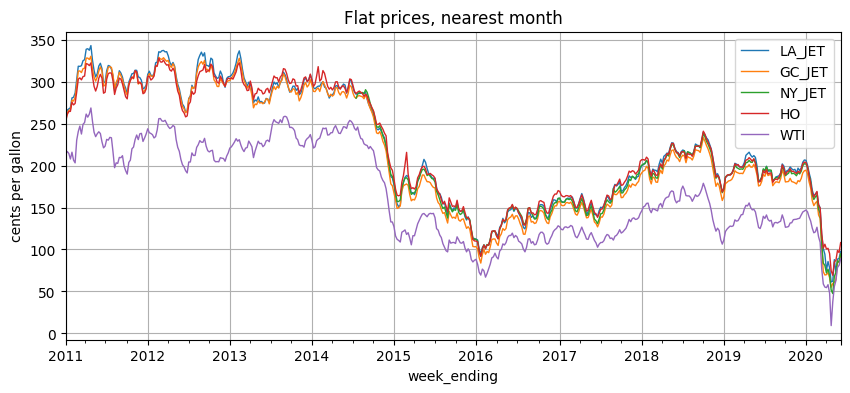

In [19]:
fig, ax = plt.subplots()
for name in ['LA_JET', 'GC_JET', 'NY_JET', 'HO', 'WTI']:
    S[name].plot(ax=ax, label=name, lw=1)
ax.set_ylabel('cents per gallon')
ax.set_title('Flat prices, nearest month')
ax.legend()
plt.show()

**What this chart shows — flat prices move together.**

Five lines: LA, Gulf Coast, NY jet, heating oil, WTI crude. They all rise and fall together because crude oil drags everything. Lesson for a reviewer: you cannot trade LA jet alone on regional news — you must subtract out the common oil move first. That is why the next charts show spreads, not levels.


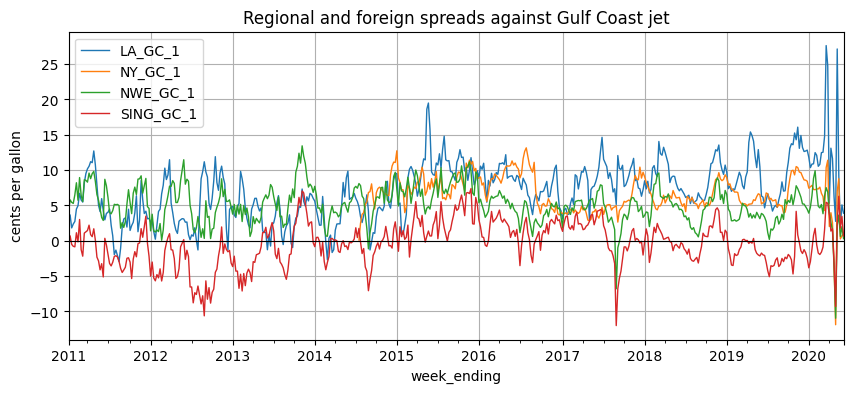

In [20]:
fig, ax = plt.subplots()
for name in ['LA_GC_1', 'NY_GC_1', 'NWE_GC_1', 'SING_GC_1']:
    S[name].plot(ax=ax, label=name, lw=1)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('cents per gallon')
ax.set_title('Regional and foreign spreads against Gulf Coast jet')
ax.legend()
plt.show()

**What this chart shows — regional gaps are bounded.**

LA minus Gulf Coast, NY minus Gulf Coast, Europe and Singapore vs Gulf Coast. Unlike crude which wanders from 50 to 300, these wobble around a few cents above or below zero and cross it. That visual wobble is the whole trading hope: if it stretches too far, it tends to snap back. If instead it drifted forever, there would be nothing to trade.


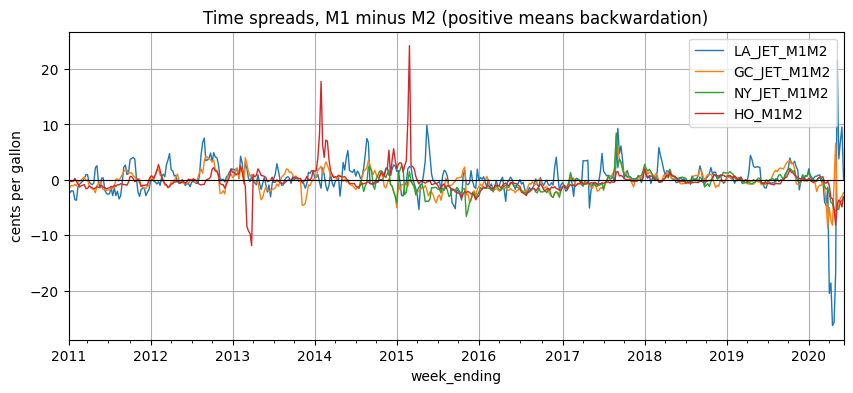

In [21]:
fig, ax = plt.subplots()
for name in ['LA_JET_M1M2', 'GC_JET_M1M2', 'NY_JET_M1M2', 'HO_M1M2']:
    S[name].plot(ax=ax, label=name, lw=1)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('cents per gallon')
ax.set_title('Time spreads, M1 minus M2 (positive means backwardation)')
ax.legend()
plt.show()

**What this chart shows — urgency over time.**

Each line is front-month minus second-month for one product. Above zero means buyers pay extra for fuel now rather than later — the market is tight today. Below zero means plenty today, tight later. Watch how fast they flip sign: that flipping speed is what later becomes "half-life."


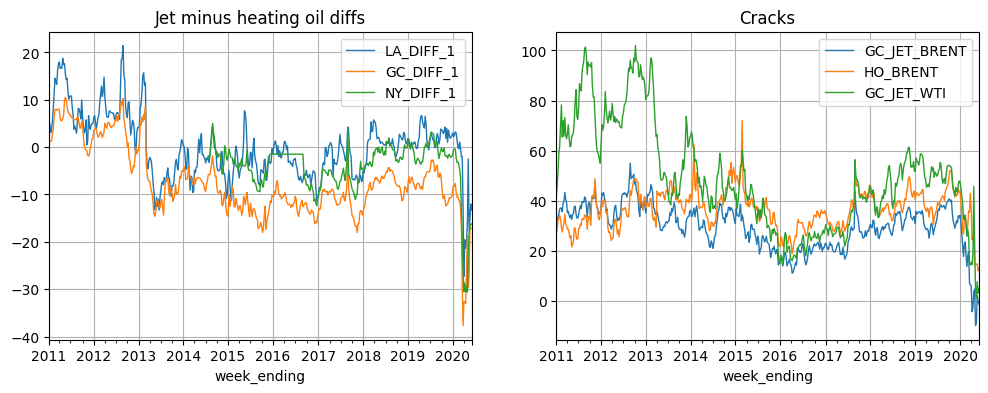

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name in ['LA_DIFF_1', 'GC_DIFF_1', 'NY_DIFF_1']:
    S[name].plot(ax=axes[0], label=name, lw=1)
axes[0].set_title('Jet minus heating oil diffs')
axes[0].legend()
for name in ['GC_JET_BRENT', 'HO_BRENT', 'GC_JET_WTI']:
    S[name].plot(ax=axes[1], label=name, lw=1)
axes[1].set_title('Cracks')
axes[1].legend()
plt.show()

**What this chart shows — refinery margins wander.**

Left panel: jet minus heating oil diffs. Right: jet and heating oil minus crude (cracks). These drift for years and even go negative around 2013. A reviewer should notice the contrast: regional spreads look springy, cracks look like they wander. That is why later only one crack (HO_BRENT) survives the shortlist, and even it struggles.


## 6. Stationarity

ADF: null = random walk. KPSS: null = fixed mean; p reported between 0.01 and 0.10. Threshold: 0.05.

| ADF p  | KPSS p | Verdict        |
| ------ | ------ | -------------- |
| < 0.05 | ≥ 0.05 | fixed level    |
| ≥ 0.05 | < 0.05 | wanders        |
| < 0.05 | < 0.05 | shifting level |
| ≥ 0.05 | ≥ 0.05 | unclear        |


In [23]:
STAT = pd.DataFrame(index=S.columns, columns=['group', 'first_week', 'weeks', 'adf_p', 'kpss_p', 'verdict'])
for name in S.columns:
    s = PRE[name].dropna()
    adf_p = adfuller(s, autolag='AIC')[1]
    kpss_p = kpss(s, regression='c', nlags='auto')[1]
    if adf_p < 0.05 and kpss_p >= 0.05:
        verdict = 'fixed level'
    elif adf_p >= 0.05 and kpss_p < 0.05:
        verdict = 'wanders'
    elif adf_p < 0.05 and kpss_p < 0.05:
        verdict = 'shifting level'
    else:
        verdict = 'unclear'
    STAT.loc[name] = [GROUP[name], s.index.min().date(), len(s), round(adf_p, 3), round(kpss_p, 3), verdict]
STAT

,group,first_week,weeks,adf_p,kpss_p,verdict
LA_JET,flat,2011-01-07,478,0.732,0.01,wanders
GC_JET,flat,2011-01-07,478,0.766,0.01,wanders
NY_JET,flat,2014-07-18,294,0.049,0.049,shifting level
HO,flat,2011-01-07,478,0.749,0.01,wanders
WTI,flat,2011-01-07,478,0.585,0.01,wanders
BRENT,flat,2011-01-07,478,0.737,0.01,wanders
GASOIL,flat,2011-01-07,478,0.737,0.01,wanders
NWE_JET,flat,2011-01-07,478,0.784,0.01,wanders
SING_KERO,flat,2011-01-07,478,0.78,0.01,wanders
LA_GC_1,regional,2011-01-07,478,0.0,0.01,shifting level


**What this block did — the wander-vs-snapback test (your first time-series idea).**

Imagine two dogs: one wanders wherever it wants (a random walk — like crude oil price), the other runs away but always comes back home (mean-reverting — like LA minus Gulf Coast). This block runs two formal sniff tests on every spread:

- ADF asks "can I prove this comes back?" If p < 0.05, yes.
- KPSS asks "can I prove this stays fixed?" If p >= 0.05, yes.

Four outcomes: fixed level (ideal spring), wanders (no trade), shifting level (springy but home moved — e.g. refinery outage), unclear. As a reviewer: this table is the single most important filter. Only springs get traded.


In [24]:
STAT.groupby(['group', 'verdict']).size().unstack(fill_value=0)

verdict,fixed level,shifting level,wanders
group,,,
arb,1,1,0
crack,1,0,3
diff,0,2,1
flat,0,1,8
foreign,1,1,0
other,0,1,2
regional,2,3,0
time,20,4,3


**What this block did — counting springs vs wanderers by family.**

It collapses the big test table into counts: how many flats wander, how many time spreads are fixed, and so on. As a reviewer, read one line: flats 8 of 9 wander (no trade on levels), time spreads 20 of 27 fixed (tradeable). This is the executive summary of the previous block.


In [25]:
# stationarity of flat-price weekly changes
FLAT = GROUP.index[GROUP == 'flat']
FLAT_CHANGES = pd.DataFrame(index=FLAT, columns=['adf_p_changes', 'kpss_p_changes'])
for name in FLAT:
    s = CHANGES[name].dropna()
    FLAT_CHANGES.loc[name] = [round(adfuller(s, autolag='AIC')[1], 3), round(kpss(s, regression='c', nlags='auto')[1], 3)]
FLAT_CHANGES

,adf_p_changes,kpss_p_changes
LA_JET,0.0,0.1
GC_JET,0.0,0.1
NY_JET,0.0,0.1
HO,0.0,0.1
WTI,0.0,0.1
BRENT,0.0,0.1
GASOIL,0.0,0.1
NWE_JET,0.0,0.1
SING_KERO,0.0,0.1


**What this block did — checking weekly changes instead of levels.**

Levels wander, but their week-to-week _changes_ should be well-behaved. This block re-runs the same two tests on changes in flat prices. Result: all stationary. Why care? Later models will use changes and gaps, not raw levels, precisely because changes don't drift forever. Think of it as: the position of a drunk wanders, but his steps are still small and centred.


- Flat prices: 8 of 9 wander; NY jet (from 2014-07-18) ADF 0.049. Weekly changes: stationary.
- Time spreads: 20 of 27 fixed level; NY jet and NWE_JET_M1M2 shifting; Brent wanders.
- Regional spreads: ADF ≤ 0.001. LA_GC_1 shifting level (2015: Torrance refinery outage). NY_GC_1 fixed level.
- Most cracks and diffs: wander or shift. Diffs turn negative in 2013; WTI crack = Brent crack + BRENT_WTI.
- Shortlist rule: ADF; KPSS reported.


## 7. ACF and PACF

Half-life = log(0.5) / log(phi); phi = lag-1 coefficient of the level. Shaded band: 95 percent range around zero. Five-day averaging gives weekly changes a lag-1 correlation of 0.235 (Working, 1960).


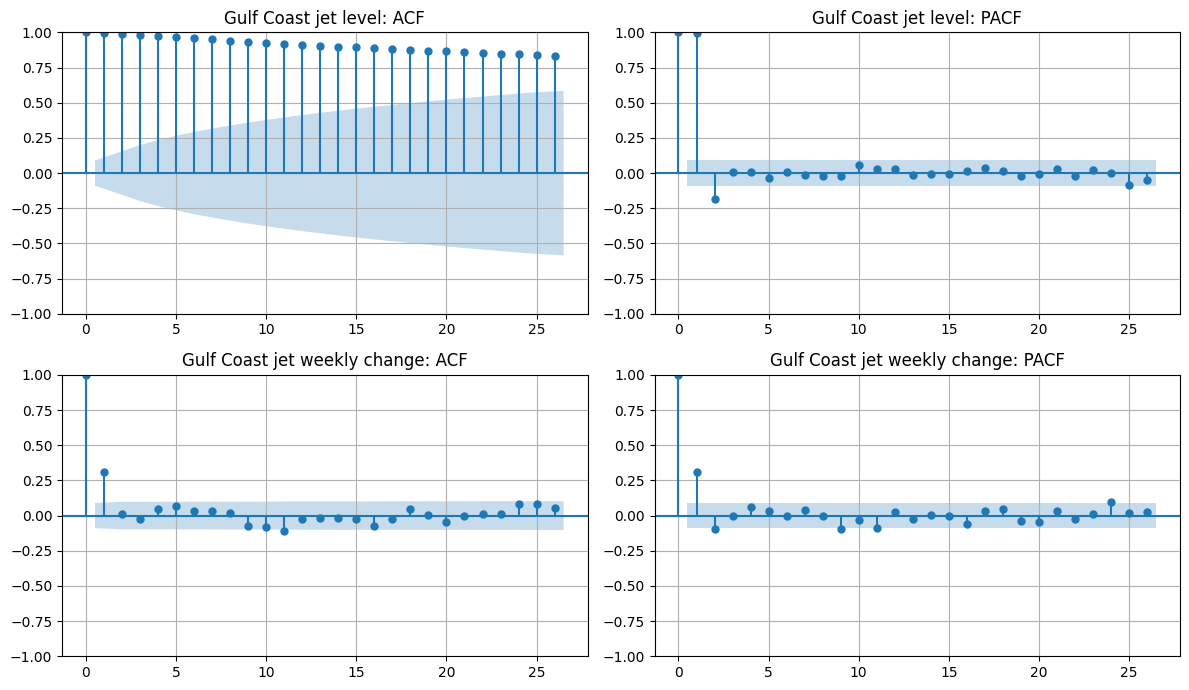

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
plot_acf(PRE['GC_JET'].dropna(), lags=26, ax=axes[0, 0], title='Gulf Coast jet level: ACF')
plot_pacf(PRE['GC_JET'].dropna(), lags=26, ax=axes[0, 1], method='ywm', title='Gulf Coast jet level: PACF')
plot_acf(CHANGES['GC_JET'].dropna(), lags=26, ax=axes[1, 0], title='Gulf Coast jet weekly change: ACF')
plot_pacf(CHANGES['GC_JET'].dropna(), lags=26, ax=axes[1, 1], method='ywm', title='Gulf Coast jet weekly change: PACF')
plt.tight_layout()
plt.show()

**What this chart shows — memory in Gulf Coast jet (ACF/PACF explained).**

Top-left (ACF of level): bars decay slowly — today's price looks like yesterday's. That is memory. Bottom-left (ACF of changes): only the first bar sticks out — weekly moves barely remember each other. Top-right/bottom-right (PACF): how many past weeks directly matter after removing the chain effect. As a reviewer: slow-decaying ACF = wandering level; quick cut-off = springy spread. You will see the same four-panel layout for LA minus Gulf Coast next, where the decay is much faster.


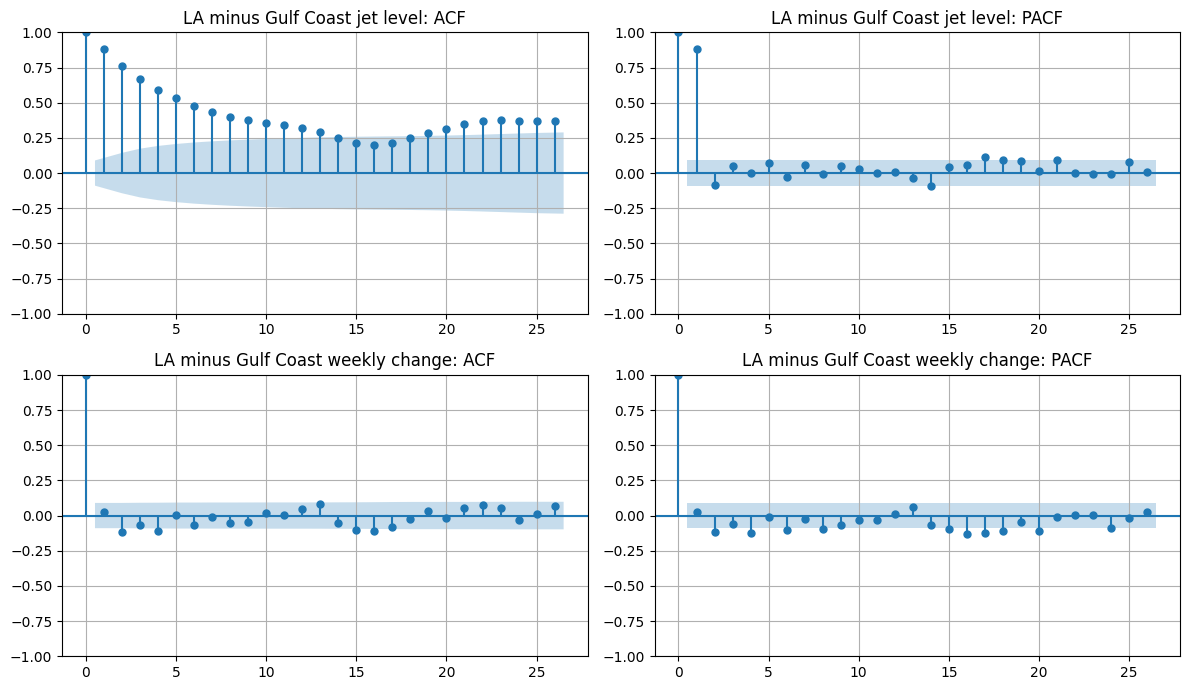

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
plot_acf(PRE['LA_GC_1'].dropna(), lags=26, ax=axes[0, 0], title='LA minus Gulf Coast jet level: ACF')
plot_pacf(PRE['LA_GC_1'].dropna(), lags=26, ax=axes[0, 1], method='ywm', title='LA minus Gulf Coast jet level: PACF')
plot_acf(CHANGES['LA_GC_1'].dropna(), lags=26, ax=axes[1, 0], title='LA minus Gulf Coast weekly change: ACF')
plot_pacf(CHANGES['LA_GC_1'].dropna(), lags=26, ax=axes[1, 1], method='ywm', title='LA minus Gulf Coast weekly change: PACF')
plt.tight_layout()
plt.show()

**What this chart shows — the same memory test on LA minus Gulf Coast.**

Compare with the previous chart: here the top-left ACF bars die out within a handful of weeks instead of lingering for months. That fast fade is visual proof of snap-back. The bottom panels show weekly changes have almost no memory — each week's move is mostly fresh news. This contrast (slow fade = wander, fast fade = spring) is the intuition behind every number in the memory table next.


In [28]:
MEMORY = pd.DataFrame(index=S.columns, columns=['phi', 'half_life_weeks', 'pacf_lags_that_matter', 'typical_weekly_move', 'acf1_of_changes'])
for name in S.columns:
    s = PRE[name].dropna()
    fit = sm.OLS(s.values[1:], sm.add_constant(s.values[:-1])).fit()
    phi = fit.params[1]
    if 0 < phi < 1:
        half_life = np.log(0.5) / np.log(phi)
    else:
        half_life = np.inf
    band = 1.96 / np.sqrt(len(s))
    p = pacf(s, nlags=8, method='ywm')[1:]
    lags_that_matter = int((np.abs(p) > band).sum())
    ch = s.diff().dropna()
    MEMORY.loc[name] = [round(phi, 3), round(half_life, 1), lags_that_matter, round(ch.std(), 2), round(ch.autocorr(1), 2)]
MEMORY.join(GROUP.rename('group'))

,phi,half_life_weeks,pacf_lags_that_matter,typical_weekly_move,acf1_of_changes,group
LA_JET,0.997,206.6,2,6.32,0.34,flat
GC_JET,0.997,260.6,2,6.03,0.31,flat
NY_JET,0.978,30.5,2,5.73,0.34,flat
HO,0.996,192.2,2,6.37,0.28,flat
WTI,0.995,145.7,3,5.51,0.27,flat
BRENT,0.997,224.9,2,5.56,0.28,flat
GASOIL,0.997,236.4,2,6.05,0.32,flat
NWE_JET,0.998,302.8,2,5.73,0.32,flat
SING_KERO,0.998,302.5,2,5.68,0.32,flat
LA_GC_1,0.888,5.8,1,1.83,0.03,regional


**What this block did — measuring memory as half-life (your second time-series idea).**

It fits "next week = constant + phi × this week" for every spread. Phi near 1 means strong memory (wanders). Phi 0.89 means weak memory (springs back). Half-life translates phi into English: how many weeks until half the gap closes? LA minus Gulf Coast: 5.8 weeks. LA time spread: 2 weeks. Crude time spreads: 9-28 weeks (too slow to trade). It also records typical weekly move (is there enough motion to cover costs?) and how many past weeks matter (PACF lags). As a reviewer: half-life ≤ 8 and move ≥ 1 cent become two of the four shortlist rules.


In [29]:
# lag-1 correlation of changes against 0.235
MEMORY.loc[FLAT, ['acf1_of_changes']].assign(averaging_effect=0.235)

,acf1_of_changes,averaging_effect
LA_JET,0.34,0.235
GC_JET,0.31,0.235
NY_JET,0.34,0.235
HO,0.28,0.235
WTI,0.27,0.235
BRENT,0.28,0.235
GASOIL,0.32,0.235
NWE_JET,0.32,0.235
SING_KERO,0.32,0.235


**What this block did — the averaging trap.**

Weekly prices here are averages of 5 daily prices. Averaging mechanically creates fake week-to-week memory of about 0.235 even if daily moves are pure noise (Working, 1960). This block shows flat-price changes have 0.27-0.34 — only slightly above 0.235. Lesson: don't get excited that "this week predicts next week" for levels; most of that is just the averaging. Real signal must beat 0.235, which is why we trade springy spreads, not levels.


- Flat prices: phi 0.978 to 0.998; lag-1 correlation of changes 0.27 to 0.34 (averaging: 0.235).
- Regional, foreign, arb spreads: half-life 3.5 to 6.9 weeks (LA_GC_1 5.8).
- Product M1-M2: 2.0 to 7.3 weeks (LA jet, HO 2.0; GC jet 4.4). Crude: 9 to 28 weeks.
- Most diffs and cracks: 9 to 51 weeks; HO_BRENT 7.7.
- Spread changes: lag-1 correlation -0.26 to 0.18; PACF: 1 to 3 lags for most spreads.


## 8. Curve factors (PCA of M1-M6 weekly changes)


In [30]:
PCA_SHARES = pd.DataFrame(columns=['whole_curve', 'front_vs_back', 'middle_vs_ends', 'corr_M1_M2_changes'])
PCA_LOADINGS = {}
for tag, root, kind in CURVES:
    cols = [f'{root}{n} {kind}' for n in range(1, 7)]
    X = CG.loc[:PRE_COVID_END, cols].diff().dropna()
    values, vectors = np.linalg.eigh(np.cov(X.values.T))
    order = np.argsort(values)[::-1]
    values = values[order]
    vectors = vectors[:, order]
    shares = values / values.sum()
    PCA_SHARES.loc[tag] = [shares[0], shares[1], shares[2], X.iloc[:, 0].corr(X.iloc[:, 1])]
    PCA_LOADINGS[tag] = vectors[:, :3]
PCA_SHARES.astype(float).round(4)

,whole_curve,front_vs_back,middle_vs_ends,corr_M1_M2_changes
LA_JET,0.9792,0.0122,0.0040,0.9709
GC_JET,0.9870,0.0077,0.0027,0.9901
NY_JET,0.9883,0.0074,0.0024,0.9851
HO,0.9795,0.0174,0.0021,0.9650
WTI,0.9918,0.0075,0.0005,0.9965
BRENT,0.9945,0.0050,0.0005,0.9948
GASOIL,0.9929,0.0056,0.0008,0.9938
NWE_JET,0.9948,0.0041,0.0006,0.9958
SING_KERO,0.9952,0.0036,0.0005,0.9967


**What this block did — collapsing 6 delivery months into 2 (PCA explained).**

Each product has 6 monthly prices. Do we need all 6? PCA asks: what few patterns explain almost all weekly moves? Answer: pattern 1 (whole curve up/down) explains 98-99.5%, pattern 2 (front vs back) 0.4-1.7%, pattern 3 almost nothing. So we keep M1 (the level) and M1-M2 (the slope) and drop the rest. As a reviewer: this is dimensionality reduction — 6 numbers compressed to 2 with almost no loss, which keeps later models simple and honest.


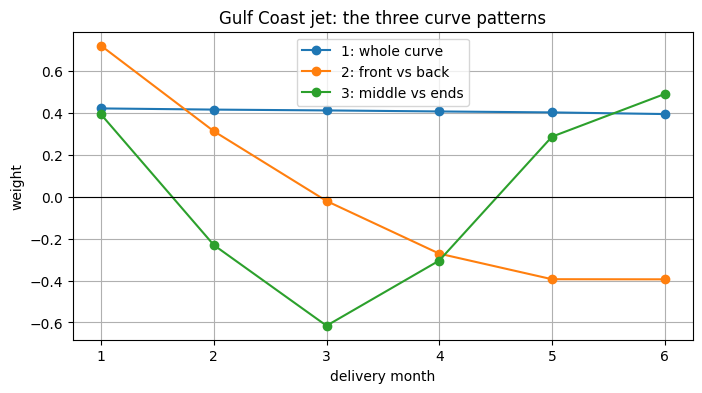

In [31]:
L = PCA_LOADINGS['GC_JET']
fig, ax = plt.subplots(figsize=(8, 4))
for i, label in enumerate(['1: whole curve', '2: front vs back', '3: middle vs ends']):
    sign = np.sign(L[0, i]) if L[0, i] != 0 else 1
    ax.plot(range(1, 7), sign * L[:, i], marker='o', label=label)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('delivery month')
ax.set_ylabel('weight')
ax.set_title('Gulf Coast jet: the three curve patterns')
ax.legend()
plt.show()

**What this chart shows — the three curve shapes.**

For Gulf Coast jet: line 1 is flat across all 6 months (whole curve moves together), line 2 tilts (front vs back), line 3 humps (middle vs ends). The flat line dominates — that is the 98%+ from the table. You now see why M1 captures almost everything and M1-M2 captures the tilt. Nothing else is worth modelling.


Jet M1-M2 = diff M1-M2 + HO M2-M3. Correlation of jet time-spread changes with HO spreads:


In [32]:
JET_VS_HO = pd.DataFrame(columns=['corr_with_HO_M1M2', 'corr_with_HO_M2M3'])
HO_M2M3_CHANGE = CHANGES['HO_M2M3']
for tag in ['LA_JET', 'GC_JET', 'NY_JET']:
    JET_VS_HO.loc[f'{tag}_M1M2'] = [CHANGES[f'{tag}_M1M2'].corr(CHANGES['HO_M1M2']), CHANGES[f'{tag}_M1M2'].corr(HO_M2M3_CHANGE)]
JET_VS_HO.astype(float).round(2)

,corr_with_HO_M1M2,corr_with_HO_M2M3
LA_JET_M1M2,0.02,0.06
GC_JET_M1M2,0.17,0.22
NY_JET_M1M2,0.25,0.36


**What this block did — are jet time spreads just heating-oil in disguise?**

Because jet diffs are priced off heating oil, you might worry LA jet M1-M2 is just HO M1-M2 renamed. This block correlates their weekly changes. LA: 0.02-0.06 (independent), Gulf: 0.17-0.22, NY: 0.25-0.36 (partially linked). As a reviewer: LA time spreads carry their own regional information — they are not redundant copies of heating oil.


- Whole curve: 97.9 to 99.5 percent of variance; front against back: 0.4 to 1.7; curvature ≤ 0.4. M1-M2 change correlation: 0.965 to 0.997.
- Use M1 (level) and M1-M2 (slope).
- Jet M1-M2 against HO M1-M2 / HO M2-M3: LA 0.02 / 0.06, GC 0.17 / 0.22, NY 0.25 / 0.36.


## 9. Redundancy

Identities (16 series): `X_M1M3 = X_M1M2 + X_M2M3`; `LA_NY_1 = LA_GC_1 - NY_GC_1`; `LA_GC_2 = LA_GC_1 - LA_JET_M1M2 + GC_JET_M1M2`; `GC_JET_WTI = GC_JET_BRENT + BRENT_WTI`. Kept: M1 regional spreads, Brent cracks.


In [33]:
IDENTITY = pd.DataFrame(columns=['largest_gap_cents'])
IDENTITY.loc['LA_NY_1 = LA_GC_1 - NY_GC_1'] = (S['LA_NY_1'] - (S['LA_GC_1'] - S['NY_GC_1'])).abs().max()
IDENTITY.loc['NY_NWE_1 = NY_GC_1 - NWE_GC_1'] = (S['NY_NWE_1'] - (S['NY_GC_1'] - S['NWE_GC_1'])).abs().max()
IDENTITY.loc['LA_SING_1 = LA_GC_1 - SING_GC_1'] = (S['LA_SING_1'] - (S['LA_GC_1'] - S['SING_GC_1'])).abs().max()
IDENTITY.loc['LA_GC_2 = LA_GC_1 - LA_JET_M1M2 + GC_JET_M1M2'] = (S['LA_GC_2'] - (S['LA_GC_1'] - S['LA_JET_M1M2'] + S['GC_JET_M1M2'])).abs().max()
IDENTITY.loc['NY_GC_2 = NY_GC_1 - NY_JET_M1M2 + GC_JET_M1M2'] = (S['NY_GC_2'] - (S['NY_GC_1'] - S['NY_JET_M1M2'] + S['GC_JET_M1M2'])).abs().max()
IDENTITY.loc['GC_JET_WTI = GC_JET_BRENT + BRENT_WTI'] = (S['GC_JET_WTI'] - (S['GC_JET_BRENT'] + S['BRENT_WTI'])).abs().max()
IDENTITY.loc['HO_WTI = HO_BRENT + BRENT_WTI'] = (S['HO_WTI'] - (S['HO_BRENT'] + S['BRENT_WTI'])).abs().max()
for tag, root, kind in CURVES:
    IDENTITY.loc[f'{tag}_M1M3 = {tag}_M1M2 + {tag}_M2M3'] = (S[f'{tag}_M1M3'] - (S[f'{tag}_M1M2'] + S[f'{tag}_M2M3'])).abs().max()
IDENTITY.astype(float).round(6)

,largest_gap_cents
LA_NY_1 = LA_GC_1 - NY_GC_1,0.0
NY_NWE_1 = NY_GC_1 - NWE_GC_1,0.0
LA_SING_1 = LA_GC_1 - SING_GC_1,0.0
LA_GC_2 = LA_GC_1 - LA_JET_M1M2 + GC_JET_M1M2,0.0
NY_GC_2 = NY_GC_1 - NY_JET_M1M2 + GC_JET_M1M2,0.0
GC_JET_WTI = GC_JET_BRENT + BRENT_WTI,0.0
HO_WTI = HO_BRENT + BRENT_WTI,0.0
LA_JET_M1M3 = LA_JET_M1M2 + LA_JET_M2M3,0.0
GC_JET_M1M3 = GC_JET_M1M2 + GC_JET_M2M3,0.0
NY_JET_M1M3 = NY_JET_M1M2 + NY_JET_M2M3,0.0


**What this block did — finding exact duplicates (identities).**

Some spreads are arithmetic copies: M1-M3 always equals (M1-M2)+(M2-M3); LA minus NY always equals (LA minus Gulf) minus (NY minus Gulf). This block verifies each identity holds to tiny fractions of a cent. Why bother? If you kept both the original and the copy, later models would double-count the same information and statistics would break. The copies are listed for deletion next.


In [34]:
# remove identities
REBUILT = ['LA_NY_1', 'NY_NWE_1', 'LA_SING_1', 'LA_GC_2', 'NY_GC_2', 'GC_JET_WTI', 'HO_WTI'] + [f'{tag}_M1M3' for tag, root, kind in CURVES]
CANDIDATES = [name for name in S.columns if GROUP[name] != 'flat' and name not in REBUILT]
print(len(CANDIDATES), 'candidates:', CANDIDATES)

30 candidates: ['LA_GC_1', 'NY_GC_1', 'NWE_GC_1', 'SING_GC_1', 'LA_JET_M1M2', 'LA_JET_M2M3', 'GC_JET_M1M2', 'GC_JET_M2M3', 'NY_JET_M1M2', 'NY_JET_M2M3', 'HO_M1M2', 'HO_M2M3', 'WTI_M1M2', 'WTI_M2M3', 'BRENT_M1M2', 'BRENT_M2M3', 'GASOIL_M1M2', 'GASOIL_M2M3', 'NWE_JET_M1M2', 'NWE_JET_M2M3', 'SING_KERO_M1M2', 'SING_KERO_M2M3', 'LA_DIFF_1', 'GC_DIFF_1', 'NY_DIFF_1', 'GC_JET_BRENT', 'HO_BRENT', 'BRENT_WTI', 'HO_GASOIL', 'NWE_JET_GASOIL']


**What this block did — deleting the duplicates.**

It names the 16 identity series and keeps the 30 independent candidates. Rule going forward: keep M1 regional spreads and Brent cracks, drop the rebuildable copies. As a reviewer: from 46 built series to 30 candidates — the rest of the notebook tests only these 30, so no hidden double-counting.


Correlation of weekly changes, 2014-07-18 to 2020-02-28.


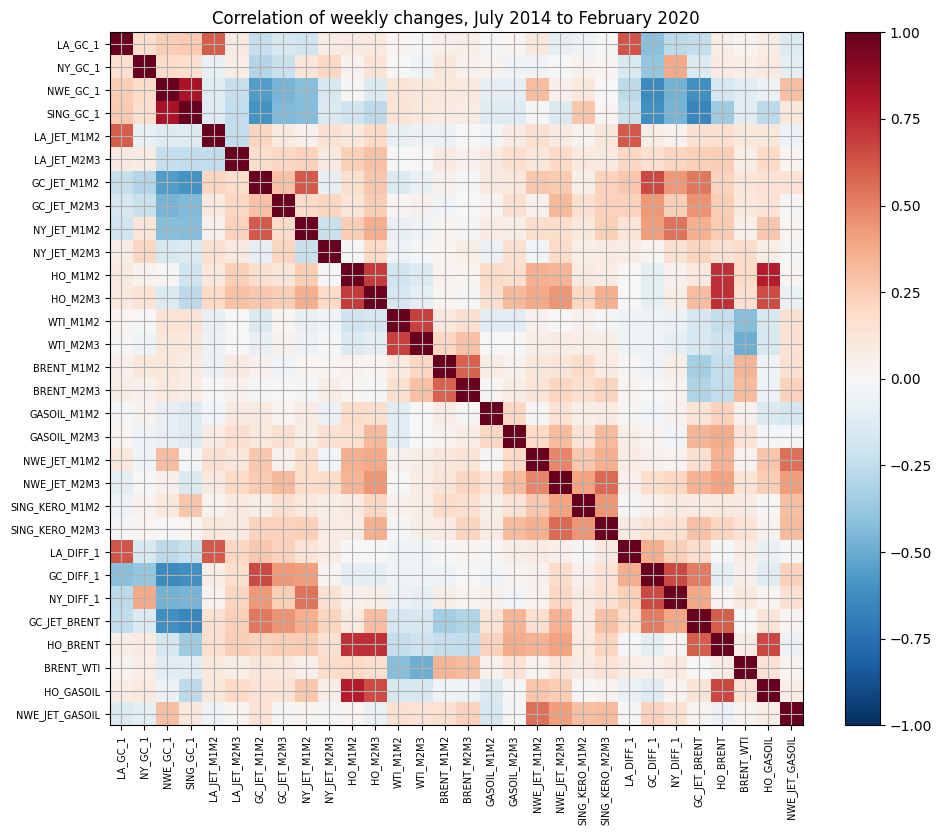

In [35]:
CORR = CHANGES.loc[NY_CLEAN_START:, CANDIDATES].corr()
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(CORR.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(CANDIDATES)))
ax.set_xticklabels(CANDIDATES, rotation=90, fontsize=7)
ax.set_yticks(range(len(CANDIDATES)))
ax.set_yticklabels(CANDIDATES, fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title('Correlation of weekly changes, July 2014 to February 2020')
plt.show()

**What this chart shows — which spreads move together (correlation map).**

A grid where dark red means "these two spreads jump together every week" and dark blue means "they jump opposite." You can see blocks: LA family together, Gulf Coast family together, heating-oil family together. As a reviewer: this is the visual justification for clustering next — we should not pick four spreads that are all secretly the same trade.


In [36]:
# clusters: mean |correlation| above 0.5
DIST = 1 - CORR.abs()
Z = linkage(squareform(DIST.values, checks=False), method='average')
CLUSTER = pd.Series(fcluster(Z, t=0.5, criterion='distance'), index=CANDIDATES, name='cluster')
for c in sorted(CLUSTER.unique()):
    members = CLUSTER.index[CLUSTER == c].tolist()
    if len(members) > 1:
        print('cluster', c, ':', members)
print('spreads alone in their own cluster:', CLUSTER.index[CLUSTER.map(CLUSTER.value_counts()) == 1].tolist())

cluster 1 : ['BRENT_M1M2', 'BRENT_M2M3']
cluster 2 : ['WTI_M1M2', 'WTI_M2M3']
cluster 4 : ['NWE_JET_M1M2', 'NWE_JET_GASOIL']
cluster 5 : ['NWE_JET_M2M3', 'SING_KERO_M2M3']
cluster 7 : ['HO_M1M2', 'HO_M2M3', 'HO_BRENT', 'HO_GASOIL']
cluster 11 : ['LA_GC_1', 'LA_JET_M1M2', 'LA_DIFF_1']
cluster 12 : ['GC_JET_M1M2', 'NY_JET_M1M2']
cluster 13 : ['NWE_GC_1', 'SING_GC_1', 'GC_DIFF_1', 'NY_DIFF_1', 'GC_JET_BRENT']
spreads alone in their own cluster: ['NY_GC_1', 'LA_JET_M2M3', 'GC_JET_M2M3', 'NY_JET_M2M3', 'GASOIL_M1M2', 'GASOIL_M2M3', 'SING_KERO_M1M2', 'BRENT_WTI']


**What this block did — grouping look-alikes into clusters.**

It turns the correlation map into families: any two spreads whose weekly moves correlate above 0.5 on average join one cluster. Output examples: LA cluster (LA minus Gulf, LA time spread, LA diff — all driven by LA price), Gulf Coast cluster, heating-oil cluster. Spreads alone in their cluster are unique trades. Later the shortlist takes only the biggest mover per cluster, so the final four are genuinely different bets.


VIF = 1 / (1 - R²) of each series on the others; above 10: collinear.


In [37]:
X = CHANGES.loc[NY_CLEAN_START:, CANDIDATES].dropna()
XC = sm.add_constant(X)
VIF = pd.Series([variance_inflation_factor(XC.values, i) for i in range(1, XC.shape[1])], index=CANDIDATES, name='vif')
VIF.sort_values(ascending=False).round(1)

HO_BRENT          35.7
GC_DIFF_1         31.1
GC_JET_BRENT      21.6
NY_DIFF_1         15.9
HO_M1M2           14.6
LA_GC_1           13.5
NWE_GC_1          11.4
NY_GC_1           10.2
SING_GC_1          9.6
LA_DIFF_1          8.6
HO_GASOIL          6.1
HO_M2M3            4.8
LA_JET_M1M2        4.6
GC_JET_M1M2        3.7
NWE_JET_M1M2       3.6
NY_JET_M1M2        3.0
WTI_M2M3           3.0
NWE_JET_M2M3       2.9
NWE_JET_GASOIL     2.8
BRENT_WTI          2.5
LA_JET_M2M3        2.5
SING_KERO_M1M2     2.3
SING_KERO_M2M3     2.3
BRENT_M2M3         2.2
WTI_M1M2           2.1
BRENT_M1M2         2.0
GC_JET_M2M3        1.8
NY_JET_M2M3        1.8
GASOIL_M1M2        1.8
GASOIL_M2M3        1.7
Name: vif, dtype: float64

**What this block did — the double-counting alarm (VIF explained).**

VIF asks: "can I rebuild this spread from all the other spreads?" VIF = 1 means unique; VIF above 10 means mostly redundant. Eight series flash red (HO_BRENT 35.7, GC_DIFF_1 31.1). Think of three friends who always vote together — counting all three as independent votes is dishonest. High VIF is why the shortlist takes one per cluster instead of all of them.


In [38]:
# VIF with an identity included
X2 = CHANGES.loc[NY_CLEAN_START:, CANDIDATES + ['GC_JET_M1M3']].dropna()
XC2 = sm.add_constant(X2)
print('VIF of GC_JET_M1M3 with M1M2 and M2M3 present:', variance_inflation_factor(XC2.values, XC2.shape[1] - 1))

VIF of GC_JET_M1M3 with M1M2 and M2M3 present: inf


**What this block did — proving the alarm works.**

It deliberately adds back a known duplicate (GC M1-M3, which equals M1-M2 plus M2-M3) and shows its VIF explodes. This is a calibration check: "see, when we know something is a copy, the alarm screams." It justifies trusting the alarm on the less obvious cases above.


| Cluster      | Members                                                      | Driver              |
| ------------ | ------------------------------------------------------------ | ------------------- |
| LA           | LA_GC_1, LA_JET_M1M2, LA_DIFF_1                              | LA M1               |
| Gulf Coast   | NWE_GC_1, SING_GC_1, GC_DIFF_1, NY_DIFF_1, GC_JET_BRENT      | GC jet price        |
| Heating oil  | HO_M1M2, HO_M2M3, HO_BRENT, HO_GASOIL                        | HO                  |
| US jet curve | GC_JET_M1M2, NY_JET_M1M2                                     | US jet curve        |
| Crude        | BRENT_M1M2 + BRENT_M2M3; WTI_M1M2 + WTI_M2M3                 | crude curves        |
| Europe, Asia | NWE_JET_M1M2 + NWE_JET_GASOIL; NWE_JET_M2M3 + SING_KERO_M2M3 | NWE and Asia curves |

- VIF above 10 after identities: 8 series; HO_BRENT 35.7, GC_DIFF_1 31.1.
- `GC_DIFF_1 = GC_JET_BRENT - HO_BRENT + HO_M1M2` within 0.15 c/gal: a regression takes the diff or its parts.


## 10. Lead and lag

Cross-correlation of weekly changes, lags -2 to +2. Granger test, 2 lags, both directions. 22 tests: Bonferroni threshold 0.05 / 22 = 0.0023.


In [39]:
PAIRS = [('NWE_JET', 'NY_JET'), ('SING_KERO', 'LA_JET'), ('GC_JET', 'NY_JET'), ('GC_JET', 'LA_JET'),
         ('HO', 'GC_JET'), ('BRENT', 'GC_JET'), ('WTI', 'GC_JET'), ('BRENT', 'WTI'),
         ('NWE_GC_1', 'NY_GC_1'), ('SING_GC_1', 'LA_GC_1'), ('HO_M1M2', 'GC_JET_M1M2')]
XCORR = pd.DataFrame(columns=['x_2w_after_y', 'x_1w_after_y', 'same_week', 'x_1w_before_y', 'x_2w_before_y'])
for x, y in PAIRS:
    dx = CHANGES.loc[NY_CLEAN_START:, x]
    dy = CHANGES.loc[NY_CLEAN_START:, y]
    XCORR.loc[f'{x} -> {y}'] = [dy.corr(dx.shift(k)) for k in [-2, -1, 0, 1, 2]]
XCORR.astype(float).round(2)

,x_2w_after_y,x_1w_after_y,same_week,x_1w_before_y,x_2w_before_y
NWE_JET -> NY_JET,0.04,0.35,0.96,0.35,0.05
SING_KERO -> LA_JET,0.05,0.34,0.94,0.38,0.07
GC_JET -> NY_JET,0.02,0.33,0.99,0.35,0.04
GC_JET -> LA_JET,0.02,0.34,0.96,0.37,0.05
HO -> GC_JET,0.05,0.34,0.92,0.34,0.03
BRENT -> GC_JET,0.06,0.32,0.92,0.35,0.05
WTI -> GC_JET,0.04,0.29,0.86,0.36,0.06
BRENT -> WTI,0.08,0.33,0.93,0.30,0.07
NWE_GC_1 -> NY_GC_1,-0.06,-0.08,0.18,0.02,-0.05
SING_GC_1 -> LA_GC_1,-0.03,-0.09,0.26,-0.03,-0.05


**What this block did — does one market move first? (lead-lag explained).**

It slides one price against another by 1-2 weeks: does Singapore move this week and LA follow next week? The table shows same-week correlation is huge (0.86-0.99) but shifted correlations are near zero (-0.09 to 0.02). Translation: markets move together within the same week; nobody reliably leads. As a reviewer: this kills the hope of "trade LA next week off Singapore this week" — the edge must come from fundamentals, not price leadership.


In [40]:
GRANGER = pd.DataFrame(columns=['p_x_leads_y', 'p_y_leads_x'])
for x, y in PAIRS:
    both = CHANGES.loc[NY_CLEAN_START:, [y, x]].dropna()
    p_xy = grangercausalitytests(both[[y, x]], maxlag=[2], verbose=False)[2][0]['ssr_ftest'][1]   # x leads y
    p_yx = grangercausalitytests(both[[x, y]], maxlag=[2], verbose=False)[2][0]['ssr_ftest'][1]   # y leads x
    GRANGER.loc[f'{x} -> {y}'] = [p_xy, p_yx]
GRANGER.astype(float).round(3)

,p_x_leads_y,p_y_leads_x
NWE_JET -> NY_JET,0.120,0.797
SING_KERO -> LA_JET,0.108,0.812
GC_JET -> NY_JET,0.124,0.772
GC_JET -> LA_JET,0.280,0.788
HO -> GC_JET,0.408,0.022
BRENT -> GC_JET,0.239,0.653
WTI -> GC_JET,0.090,0.410
BRENT -> WTI,0.929,0.389
NWE_GC_1 -> NY_GC_1,0.713,0.478
SING_GC_1 -> LA_GC_1,0.698,0.372


**What this block did — the formal "who leads" test (Granger explained).**

Cross-correlation above is just eyeballing. The Granger test asks formally: "do last 2 weeks of X improve my forecast of Y beyond Y's own history?" With 22 pairs tested, luck alone would flag one, so the bar is tightened to 0.05/22 = 0.0023 (Bonferroni — like requiring stronger evidence when you take 22 shots). Smallest p is 0.022 — nobody passes. Verdict: same-week co-movement, no usable lead. This is why the project turns to EIA stocks and refinery data instead of price patterns.


- Flat pairs: same-week correlation 0.86 to 0.99; lags ±1: 0.3 to 0.4 in both directions (averaging).
- Spreads, lags ±1 and ±2: -0.09 to 0.02.
- Granger: minimum p 0.022 (GC jet to HO); all p above 0.0023. Result: same-week co-movement.


## 11. Seasonality

Level on month dummies; Wald test with Newey-West errors (8 lags).


In [41]:
SEASON = pd.DataFrame(index=CANDIDATES, columns=['r_squared_month', 'p_month'])
for name in CANDIDATES:
    d = PRE[[name]].dropna().rename(columns={name: 'y'})
    d['month'] = d.index.month
    fit = smf.ols('y ~ C(month)', data=d).fit(cov_type='HAC', cov_kwds={'maxlags': 8})
    R = np.eye(len(fit.params))[1:]
    SEASON.loc[name] = [round(fit.rsquared, 2), round(float(fit.f_test(R).pvalue), 3)]
SEASON.sort_values('r_squared_month', ascending=False)

,r_squared_month,p_month
GC_JET_M1M2,0.39,0.0
GC_JET_M2M3,0.37,0.0
NWE_GC_1,0.22,0.0
SING_GC_1,0.2,0.001
HO_M2M3,0.19,0.0
HO_BRENT,0.18,0.003
GASOIL_M1M2,0.14,0.011
WTI_M1M2,0.14,0.458
NY_GC_1,0.13,0.349
GASOIL_M2M3,0.13,0.176


**What this block did — is there a calendar season? (seasonality explained).**

It asks: does the spread depend on the month — expensive in summer driving season, cheap in winter? It fits one average per month and measures how much that explains (R²) with a robust significance test. Gulf Coast time spread: R² 0.39, highly significant — real seasonality (tight late summer, loose spring). LA minus Gulf Coast: R² 0.10, p 0.226 — no reliable season. As a reviewer: seasonality is noted but not traded here; it just warns that some spreads have a calendar rhythm.


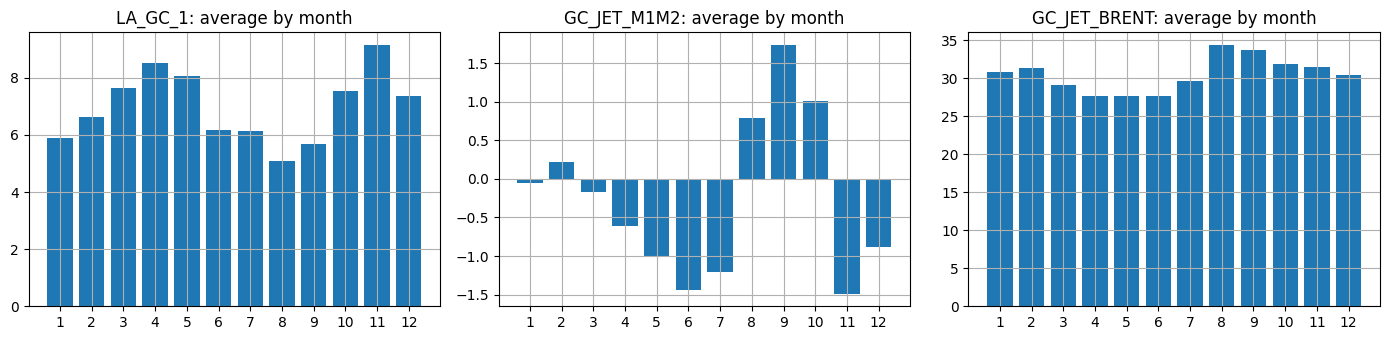

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, name in zip(axes, ['LA_GC_1', 'GC_JET_M1M2', 'GC_JET_BRENT']):
    by_month = PRE[name].groupby(PRE.index.month).mean()
    ax.bar(by_month.index, by_month.values)
    ax.set_title(f'{name}: average by month')
    ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.show()

**What this chart shows — average spread by month.**

Three bar charts: LA minus Gulf Coast, Gulf time spread, Gulf crack. Bars above zero = that month usually rich, below = usually cheap. Look for a smooth wave (season) vs random up-down (noise). Gulf time spread shows the wave; LA minus Gulf Coast does not. This picture is the visual behind the R² numbers above.


In [43]:
# seasonality excluding 2017
d = PRE[['GC_JET_M1M2']].rename(columns={'GC_JET_M1M2': 'y'}).dropna()
d = d[d.index.year != 2017]
d['month'] = d.index.month
fit = smf.ols('y ~ C(month)', data=d).fit(cov_type='HAC', cov_kwds={'maxlags': 8})
print('without 2017: R-squared', round(fit.rsquared, 2), '| p-value', round(float(fit.f_test(np.eye(len(fit.params))[1:]).pvalue), 4))
d.groupby('month')['y'].mean().round(2).to_frame('GC_JET_M1M2 average without 2017').T

without 2017: R-squared 0.38 | p-value 0.0


month,1,2,3,4,5,6,7,8,9,10,11,12
GC_JET_M1M2 average without 2017,0.06,0.25,-0.09,-0.59,-0.98,-1.42,-1.3,0.76,1.34,1.03,-1.59,-1.06


**What this block did — was the season just one hurricane?**

Gulf seasonality could be one freak event: Hurricane Harvey (2017) shut refineries and spiked the time spread. So this block deletes all of 2017 and re-runs the test. R² barely moves (0.39 to 0.38). As a reviewer: the season survives the removal of the suspect — it is a real calendar pattern, not one storm.


- GC_JET_M1M2: R² 0.39 (p < 0.001); backwardation Aug-Oct, contango Apr-Jul and Nov-Dec. Excluding 2017 (Hurricane Harvey): R² 0.38.
- GC_JET_M2M3 0.37, NWE_GC_1 0.22, SING_GC_1 0.20, HO_BRENT 0.18, LA_JET_M2M3 0.13 (p 0.002).
- LA_GC_1: R² 0.10, p 0.226.


## 12. Volatility

Rolling 13-week standard deviation of weekly changes. Flag: above 3x the pre-COVID median.


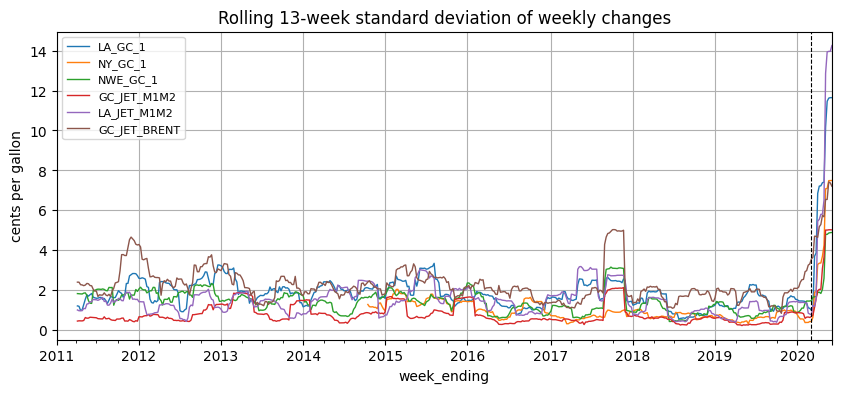

In [44]:
VOL_SERIES = ['LA_GC_1', 'NY_GC_1', 'NWE_GC_1', 'GC_JET_M1M2', 'LA_JET_M1M2', 'GC_JET_BRENT']
ROLL_SD = S[VOL_SERIES].diff().rolling(13).std()
fig, ax = plt.subplots()
for name in VOL_SERIES:
    ROLL_SD[name].plot(ax=ax, label=name, lw=1)
ax.axvline(pd.Timestamp(COVID_START), color='black', ls='--', lw=0.8)
ax.set_ylabel('cents per gallon')
ax.set_title('Rolling 13-week standard deviation of weekly changes')
ax.legend(fontsize=8)
plt.show()

**What this chart shows — when did markets go wild? (rolling volatility explained).**

Each line is the typical weekly move over the trailing 13 weeks (one quarter). Flat in calm years, spiking in stress. The dashed line is COVID March 2020: every line explodes to 11-14 cents (vs 1.5-1.8 normal). Earlier bumps mark Harvey 2017. As a reviewer: this chart justifies cutting the test sample at February 2020 — you cannot judge normal snap-back speed during an explosion.


In [45]:
PERIODS = []
for name in VOL_SERIES:
    flag = ROLL_SD[name] > 3 * ROLL_SD[name].loc[:PRE_COVID_END].median()
    start = None
    prev = None
    for week, is_high in flag.items():
        if is_high and start is None:
            start = week
        if not is_high and start is not None:
            PERIODS.append([name, start.date(), prev.date()])
            start = None
        prev = week
    if start is not None:
        PERIODS.append([name, start.date(), prev.date()])
pd.DataFrame(PERIODS, columns=['series', 'from', 'to'])

,series,from,to
0,LA_GC_1,2020-04-03,2020-06-05
1,NY_GC_1,2020-04-03,2020-06-05
2,NWE_GC_1,2020-05-08,2020-06-05
3,GC_JET_M1M2,2013-03-01,2013-03-01
4,GC_JET_M1M2,2013-03-15,2013-04-26
5,GC_JET_M1M2,2017-09-08,2017-11-24
6,GC_JET_M1M2,2020-04-03,2020-06-05
7,LA_JET_M1M2,2020-04-03,2020-06-05
8,GC_JET_BRENT,2020-05-08,2020-06-05


**What this block did — listing the wild periods.**

It flags any week where the trailing volatility is 3x the normal median and lists the stretches. Pre-COVID: only Gulf time spread around Harvey and 2013. From April 2020: everything. As a reviewer, read this as the audit trail for "fits use weeks to 2020-02-28" — the cutoff is data-driven, not cherry-picked.


- Pre-COVID flags: GC_JET_M1M2, 2013-03 to 2013-04 and 2017-09 to 2017-11 (Hurricane Harvey).
- From 2020-04: all series flagged; LA spreads 11 to 14 c/gal (pre-COVID weekly sd 1.5 to 1.8).
- Fits use weeks to 2020-02-28.


## 13. Scorecard

Shortlist rules:

1. ADF p < 0.05.
2. Half-life ≤ 8 weeks.
3. Standard deviation of weekly change ≥ 1 c/gal.
4. Outside the identity list; largest weekly move in its cluster among series passing 1 to 3.


In [46]:
SCORE = STAT.join(MEMORY).join(SEASON).join(CLUSTER).join(VIF)
SCORE['rebuilt'] = [name in REBUILT for name in SCORE.index]

SCORE['rule_1_comes_back'] = SCORE['adf_p'].astype(float) < 0.05
SCORE['rule_2_half_life'] = SCORE['half_life_weeks'].astype(float) <= 8
SCORE['rule_3_moves_1c'] = SCORE['typical_weekly_move'].astype(float) >= 1.0
PASS_1_TO_3 = SCORE['rule_1_comes_back'] & SCORE['rule_2_half_life'] & SCORE['rule_3_moves_1c']
SCORE['rule_4_best_in_cluster'] = False
for c in CLUSTER.unique():
    members = [m for m in CLUSTER.index[CLUSTER == c] if PASS_1_TO_3[m]]
    if len(members) > 0:
        best = SCORE.loc[members, 'typical_weekly_move'].astype(float).idxmax()
        SCORE.loc[best, 'rule_4_best_in_cluster'] = True

SCORE['shortlist'] = (SCORE['group'] != 'flat') & PASS_1_TO_3 & SCORE['rule_4_best_in_cluster']
SCORE.loc[CANDIDATES, ['group', 'verdict', 'half_life_weeks', 'typical_weekly_move', 'cluster', 'rule_1_comes_back', 'rule_2_half_life', 'rule_3_moves_1c', 'rule_4_best_in_cluster', 'shortlist']].sort_values(['shortlist', 'typical_weekly_move'], ascending=False)

,group,verdict,half_life_weeks,typical_weekly_move,cluster,rule_1_comes_back,rule_2_half_life,rule_3_moves_1c,rule_4_best_in_cluster,shortlist
HO_BRENT,crack,fixed level,7.7,3.01,7.0,True,True,True,True,True
LA_GC_1,regional,shifting level,5.8,1.83,11.0,True,True,True,True,True
SING_GC_1,foreign,shifting level,5.0,1.57,13.0,True,True,True,True,True
LA_JET_M2M3,time,fixed level,2.0,1.17,8.0,True,True,True,True,True
BRENT_WTI,other,wanders,33.9,2.87,3.0,False,False,True,False,False
HO_GASOIL,other,shifting level,6.8,2.43,7.0,True,True,True,False,False
GC_JET_BRENT,crack,wanders,16.8,2.35,13.0,False,False,True,False,False
LA_DIFF_1,diff,shifting level,13.6,1.97,11.0,True,False,True,False,False
HO_M1M2,time,fixed level,2.0,1.67,7.0,True,True,True,False,False
LA_JET_M1M2,time,fixed level,2.0,1.51,11.0,True,True,True,False,False


**What this block did — applying the four shortlist rules.**

All earlier measurements now combine into one scorecard with four pass/fail columns: (1) ADF proves snap-back, (2) half-life ≤ 8 weeks (fast enough to trade), (3) weekly move ≥ 1 cent (big enough to cover costs), (4) biggest mover in its cluster (not a duplicate). A spread must pass all four. Think of airport security with four gates — fail one and you don't fly. The table shows exactly which gate stopped each spread.


In [47]:
SHORTLIST = SCORE.index[SCORE['shortlist']].tolist()
print('shortlist:', SHORTLIST)
SCORE.loc[SHORTLIST, ['group', 'first_week', 'weeks', 'adf_p', 'kpss_p', 'verdict', 'half_life_weeks', 'typical_weekly_move', 'r_squared_month', 'p_month', 'vif']]

shortlist: ['LA_GC_1', 'SING_GC_1', 'LA_JET_M2M3', 'HO_BRENT']


,group,first_week,weeks,adf_p,kpss_p,verdict,half_life_weeks,typical_weekly_move,r_squared_month,p_month,vif
LA_GC_1,regional,2011-01-07,478,0.0,0.01,shifting level,5.8,1.83,0.1,0.226,13.461761
SING_GC_1,foreign,2011-01-07,478,0.0,0.014,shifting level,5.0,1.57,0.2,0.001,9.598836
LA_JET_M2M3,time,2011-01-07,478,0.0,0.1,fixed level,2.0,1.17,0.13,0.002,2.456642
HO_BRENT,crack,2011-01-07,478,0.008,0.1,fixed level,7.7,3.01,0.18,0.003,35.655280


**What this block did — announcing the final four.**

It prints the survivors: LA_GC_1 (the California premium, 1.83 cents move, 5.8-week half-life), LA_JET_M2M3 (LA curve slope), SING_GC_1 (Asia vs Gulf), HO_BRENT (heating-oil crack). Near-misses like NY minus Gulf (0.99 cents — just under the 1-cent bar) are named so you know nothing was hidden. These four names become the headline book in every later notebook and on the dashboard.


| Spread      | Series                  | Basis                                  |
| ----------- | ----------------------- | -------------------------------------- |
| LA_GC_1     | LA jet - GC jet, M1     | LA cluster; 1.83 c/gal; half-life 5.8  |
| LA_JET_M2M3 | LA jet M2 - M3          | own cluster; 1.17 c/gal; half-life 2.0 |
| SING_GC_1   | Singapore kero - GC jet | GC cluster; 1.57 c/gal; half-life 5.0  |
| HO_BRENT    | HO - Brent              | HO cluster; 3.01 c/gal; half-life 7.7  |

- Near misses: NY_GC_1, NY_JET_M1M2 (0.99 c/gal); NWE_GC_1 (1.47, GC cluster).
- LA_JET_M2M3: LA diff M3 repeats in 7 percent of weeks.
- `LA_GC_1 - SING_GC_1 = LA_SING_1` (Asia to LA import arb).


In [48]:
# save
CLEAN = S.copy()
CLEAN['month_change_week'] = MONTH_CHANGE_WEEK
CLEAN['covid_week'] = COVID_WEEK
CLEAN.to_csv('../data/prices_clean.csv')
SCORE.to_csv('../results/price_eda_scorecard.csv')
print(CLEAN.shape, SCORE.shape)

(492, 57) (55, 21)


**Reviewer recap — what just happened:** this block saved two files. `prices_clean.csv` is the cleaned price table every later notebook reads. `price_eda_scorecard.csv` is the report card with one row per spread and all its test results. Think of it as freezing the evidence so no later step can quietly change the inputs.


## Summary

| Question               | Result                                                                             |
| ---------------------- | ---------------------------------------------------------------------------------- |
| Delivery months        | M1 (level), M1-M2 (slope); M3-M6 ≤ 0.4 percent of variance                         |
| Random walks           | flat prices; most cracks and diffs; Brent time spreads                             |
| Half-life 2 to 7 weeks | regional, foreign, arb spreads; product M1-M2                                      |
| Diffs                  | priced against HO\_(n+1); regional content = flat spreads; half-life 9 to 32 weeks |
| Identities             | 16 series                                                                          |
| Lead-lag               | same-week co-movement                                                              |
| Seasonality            | GC_JET_M1M2 R² 0.39; LA_GC_1 p 0.226                                               |
| Shortlist              | LA_GC_1, LA_JET_M2M3, SING_GC_1, HO_BRENT                                          |

Next: `02_fundamentals_panel.ipynb`.
